In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#http://help.sentiment140.com/for-students
#https://www.kaggle.com/datasets/kazanova/sentiment140
df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",encoding='ISO-8859-1',header=None)

In [ ]:
df.head()

,0,1,2,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# Before moving forward with a dataset:
# Confirm if country is not available
# Confirm if it was filtered on any search phrase
# Confirm if retweets are included, if yes, drop them
# Dropn NANs/impute as appropriate

In [ ]:
df.drop(columns=[3,4], axis=1,inplace=True)

In [ ]:
df.head()

,0,1,2,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df.columns = ['Sentiment','id','date','text']

In [ ]:
df.head()

,Sentiment,id,date,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df.isna().sum().sum()

0

In [ ]:
# Function to Clean the Tweet.

import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())

# We only want the Text so :

# (@[A-Za-z0-9]+)   : Delete Anything like @hello @Letsupgrade etc
# ([^0-9A-Za-z \t]) : Delete everything other than text,number,space,tabspace
# (\w+:\/\/\S+)     : Delete https://
# ([RT]) : Remove "RT" from the tweet
# \xe2\x80\x9cguaran : Remove such tags
# b'@thedailybeast : Remove such words : SS - check if we can only remove the b' prefix instead of full word
# SS - Check if apostrophe can be retained eg: hadn't currently becomes hadn t

In [ ]:
# Drop non english tweets ********** IMPORTANT *********

In [ ]:
# Call function to get Clean tweets
df["CleanTweet"] = df['text'].apply(lambda x : clean_tweet(x))
df.head(10)

,Sentiment,id,date,text,CleanTweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that s a bummer you shoulda got david car...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...,is upset that he can t update his facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all....",no it s not behaving at all i m mad why am i h...
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,@Kwesidei not the whole crew,not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,Need a hug,need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,@Tatiana_K nope they didn't have it,k nope they didn t have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,@twittera que me muera ?,que me muera


In [ ]:
#df["CleanTweet"] = df["CleanTweet"].apply(lambda x: ' '.join([w for w in x.split() if len(w)>1]))

In [ ]:
df[df.CleanTweet.eq("")]

,Sentiment,id,date,text,CleanTweet
208,0,1467863072,Mon Apr 06 22:33:25 PDT 2009,@mandayyy,
249,0,1467874569,Mon Apr 06 22:36:27 PDT 2009,@mandayyy,
398,0,1467912842,Mon Apr 06 22:46:53 PDT 2009,@danadearmond,
430,0,1467919452,Mon Apr 06 22:48:48 PDT 2009,@anistorm,
1011,0,1468061127,Mon Apr 06 23:30:23 PDT 2009,@citizensheep,
...,...,...,...,...,...
1594186,4,2192101420,Tue Jun 16 06:30:36 PDT 2009,@LeCapitainesexy,
1594388,4,2192142286,Tue Jun 16 06:34:38 PDT 2009,@audiotherapy,
1597326,4,2192910190,Tue Jun 16 07:43:42 PDT 2009,@ashtonshay00,
1597684,4,2192984835,Tue Jun 16 07:50:07 PDT 2009,@patty4sound http://twitpic.com/7iuns -,


In [ ]:
df.drop(df.index[df.CleanTweet.eq("")], inplace=True)

In [ ]:
# Check Summary of Random Record
n = 153000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet:\n",df['Sentiment'][n])

Original tweet:
 now it's, &quot;i want to do it by myself, no by myself, no by myself mama!&quot;  what kind of terror do i cause this child?  

Clean tweet:
 now it s quot i want to do it by myself no by myself no by myself mama quot what kind of terror do i cause this child

Sentiment of the tweet:
 0


In [ ]:
# Overall Summary

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["Sentiment"]==4])))
print("Total Negative Tweets are : {}".format(len(df[df["Sentiment"]==0])))
print("Total Neutral Tweets are : {}".format(len(df[df["Sentiment"]==2])))

Total Tweets Extracted Are 1596888
Total Positive Tweets are : 798351
Total Negative Tweets are : 798537
Total Neutral Tweets are : 0


In [ ]:
df["Sentiment"].value_counts()

0    798537
4    798351
Name: Sentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

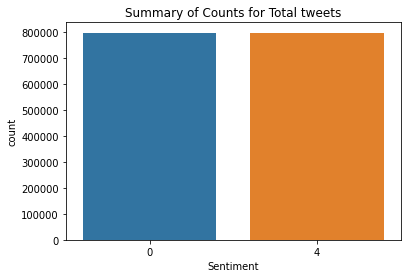

In [ ]:
#sns.countplot(df["Sentiment"],facecolor=(0, 0, 0, 0),linewidth=5,edgecolor=sns.color_palette("dark", 3))
sns.countplot(df["Sentiment"])
plt.title("Summary of Counts for Total tweets")

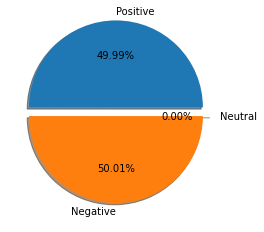

In [ ]:
# Piechart 
#string, used to label the wedges with their numeric value. The label will be placed inside the wedge. The format string will be fmt%pct.

a=len(df[df["Sentiment"]==4])
b=len(df[df["Sentiment"]==0])
c=len(df[df["Sentiment"]==2])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
#Tokenization
df['TokenizedTweet'] = df['CleanTweet'].apply(lambda x: x.split())
df.head()


,Sentiment,id,date,text,CleanTweet,TokenizedTweet
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that s a bummer you shoulda got david car...,"[awww, that, s, a, bummer, you, shoulda, got, ..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...,is upset that he can t update his facebook by ...,"[is, upset, that, he, can, t, update, his, fac..."
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,"[i, dived, many, times, for, the, ball, manage..."
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,"[my, whole, body, feels, itchy, and, like, its..."
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all....",no it s not behaving at all i m mad why am i h...,"[no, it, s, not, behaving, at, all, i, m, mad,..."


In [ ]:
from nltk.stem.porter import *
stemmer = PorterStemmer()

tokenized_tweet = df['TokenizedTweet'].apply(lambda x: [stemmer.stem(i) for i in x]) # stemming
tokenized_tweet.head()

In [ ]:
df['StemmedTweet']= tokenized_tweet.apply(lambda x: ' '.join(wrd for wrd in x))

In [ ]:
df.head()

In [ ]:
# Add Lemmatization here
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
lemmatizer = WordNetLemmatizer()
# Lemmatization
lemmatized_tweet = df['TokenizedTweet'].apply(lambda x: [lemmatizer.lemmatize(i) for i in x if i not in set(stopwords.words('english'))])
lemmatized_tweet.head()

In [ ]:
df['LemmatizedTweet']= lemmatized_tweet.apply(lambda x: ' '.join(wrd for wrd in x))

In [ ]:
#TFIDF  Vectorizer (add Count Vectorizer (Bag of Words) too if needed)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=2, max_features=10000, stop_words='english')
# TF-IDF feature matrix
tfidf = tfidf_vectorizer.fit_transform(df['CleanTweet'])


In [ ]:
df['Sentiment'].value_counts()

0    798537
4    798351
Name: Sentiment, dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

train_tfidf = tfidf[:1400000,:]
Xtest = tfidf[1400000:,:]
ytest = df['Sentiment'][1400000:]

# splitting data into training and validation set
Xtrain, Xvalid, ytrain, yvalid = train_test_split(train_tfidf, df['Sentiment'][:1400000],random_state=42, test_size=0.2) # Take 20% of train data (around 300000)

In [ ]:
# Current F1 Score = 0.7062985404177087 
lreg = LogisticRegression(max_iter=10000) 
lreg.fit(Xtrain, ytrain) # training the model

ypred = lreg.predict(Xvalid) # predicting on the validation set
f1_score(yvalid, ypred,average='weighted') # SS calculating f1 score - Complaining that target is multiclass

0.776255974613612

In [ ]:
ypred = lreg.predict(Xtest) # predicting on the validation set
f1_score(ytest, ypred,average='weighted') 

0.8375135798970289

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(Xtrain, ytrain)
rf_model.score(Xtrain, ytrain), rf_model.score(Xvalid, yvalid), rf_model.score(Xtest, ytest)

In [ ]:
#Linear SVC
from sklearn.svm import LinearSVC

Lsvm = LinearSVC(random_state=0, tol=1e-5)
Lsvm.fit(Xtrain, ytrain)
Lsvm.score(Xvalid, yvalid)
Lsvm.score(Xtest, ytest)

0.7206279712323758

In [ ]:
!pip -qq install xgboost

In [ ]:
# xgb classifier
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(Xtrain, ytrain)
xgb.score(Xtest, ytest)

0.29359839096339035

In [ ]:
!pip install catboost

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.2 MB/s 


In [ ]:
from catboost import CatBoostClassifier
catb = CatBoostClassifier()
catb.fit(Xtrain,
          ytrain,
          verbose=False)

In [ ]:
catb.score(Xvalid,yvalid)

In [ ]:
catb.score(Xtest,ytest)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
adab = AdaBoostClassifier(n_estimators=50,
                         learning_rate=1)
# Train Adaboost Classifer
adamodel = adab.fit(Xtrain, ytrain)

#Predict the response for test dataset
adamodel.score(Xvalid,yvalid)

0.6669857142857143

In [ ]:
adamodel.score(Xtest,ytest)

0.3571624476859941

In [ ]:
from sklearn.naive_bayes import GaussianNB  
classifier = GaussianNB()  
classifier.fit(Xtrain.toarray(), ytrain)

In [ ]:
ypred = classifier.predict(Xtest)

In [ ]:
f1_score(ytest,ypred)

In [ ]:
# Voting classifer
from sklearn.ensemble import VotingClassifier
lr = LogisticRegression(random_state=42)
Lsvm = LinearSVC(random_state=0, tol=1e-5)
voting = VotingClassifier(estimators=[('lr',lr), ('Lsvm',Lsvm),('rf_model', rf_model),('xgb',xgb),('catb',catb),('adab',adab)], voting='hard')
voting = voting.fit(Xtrain, ytrain)
voting.score(Xtest, ytest)